✅ Library berhasil dimuat. Memulai simulasi...
  PARAMETER SIMULASI — PROYEKSI IKLIM DAN CLIMATE PENALTY

Parameter                           Nilai                          Sumber/Keterangan
------------------------------------------------------------------------------
  Horizon simulasi                  50 tahun (2024–2074)         Periode analisis
  Total kenaikan suhu               +1.5°C                       IPCC AR6 SSP2-4.5
  Laju kenaikan suhu (α)            0.03 °C/tahun                Linear tren
  Suhu baseline T₀                  28.2 °C                      BMKG Tardamu 2025
  Penurunan daya PV                 -0.04 kW/tahun               Climate Penalty

  RINGKASAN STATISTIK SIMULASI 50 TAHUN (2024–2074)

📊 Proyeksi Suhu:
   • Suhu 2024       : 28.3 °C
   • Suhu 2074       : 31.1 °C
   • Total kenaikan  : +2.75 °C
   • Laju regresi    : +0.0194 °C/tahun  (R² = 0.0685)

⚡ Produksi PV:
   • Daya 2024       : 15.6 kW
   • Daya 2074       : 5.0 kW
   • Penurunan total : 10.6

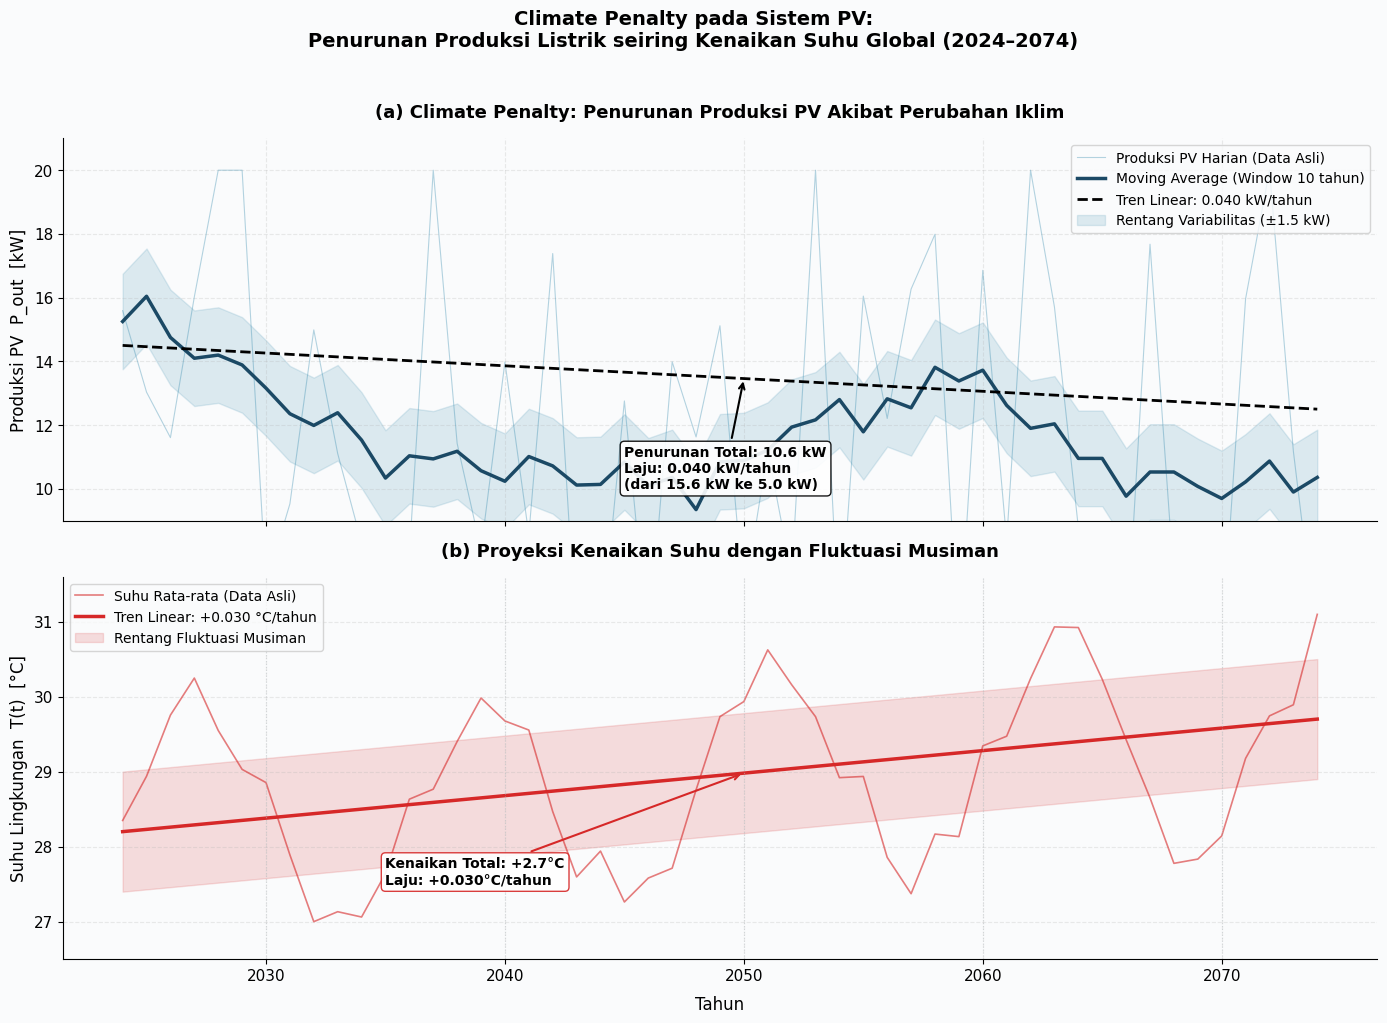

✅ Grafik disimpan: Grafik_Climate_Penalty.png


In [5]:
"""
================================================================================
SIMULASI BAGIAN 3: PROYEKSI IKLIM DAN CLIMATE PENALTY
Berdasarkan Bab III.3.2 - Perubahan Iklim dan Kejadian Ekstrem
Referensi: IPCC AR6 (SSP2-4.5), BMKG Tardamu 2025
================================================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Design System ──────────────────────────────────────────────────────────────
PALETTE = {
    'blue':    '#2E86AB',     # Produksi PV
    'red':     '#D62828',     # Suhu
    'dark_blue': '#1B4965',   # Moving average
    'gray':    '#717D7E',
    'light':   '#F2F3F4',
    'bg':      '#FAFBFC',
}

plt.rcParams.update({
    'figure.facecolor':   PALETTE['bg'],
    'axes.facecolor':     PALETTE['bg'],
    'axes.grid':          True,
    'grid.alpha':         0.25,
    'grid.linestyle':     '--',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'font.family':        'DejaVu Sans',
    'font.size':          11,
})

print("✅ Library berhasil dimuat. Memulai simulasi...")

# ============================================================================
# 1. PARAMETER DAN ASUMSI
# ============================================================================

PARAMS_IKLIM = {
    'tahun_mulai':              2024,
    'tahun_akhir':              2074,
    'horizon':                  50,
    'kenaikan_suhu_total':      1.5,
    'kenaikan_suhu_per_tahun':  0.03,
    'suhu_dasar':               28.2,
    'koefisien_suhu_beta':      0.004,
    'daya_awal':                14.5,
    'penurunan_daya_per_tahun': -0.04,
}

PARAMS_EKSTREM = {
    'pm25_baseline':             15,
    'pm25_puncak_haze':          65,
    'frekuensi_haze_awal':       0.02,
    'peningkatan_frekuensi_haze':0.003,
    'cloud_cover_baseline':      0.45,
    'cloud_cover_amplitude':     0.15,
    'koefisien_attenuasi_haze':  0.015,
    'jarak_optik':               1.0,
}

PARAMS_PV = {
    'P_src':    14.5,
    'G_clear':  1000,
    'eta_inv':  0.95,
    'L_soiling':0.03,
}

# Tampilkan ringkasan parameter
print("=" * 78)
print("  PARAMETER SIMULASI — PROYEKSI IKLIM DAN CLIMATE PENALTY")
print("=" * 78)
rows = [
    ("Horizon simulasi",               f"{PARAMS_IKLIM['horizon']} tahun (2024–2074)",             "Periode analisis"),
    ("Total kenaikan suhu",            f"+{PARAMS_IKLIM['kenaikan_suhu_total']}°C",              "IPCC AR6 SSP2-4.5"),
    ("Laju kenaikan suhu (α)",         f"{PARAMS_IKLIM['kenaikan_suhu_per_tahun']:.2f} °C/tahun","Linear tren"),
    ("Suhu baseline T₀",               f"{PARAMS_IKLIM['suhu_dasar']} °C",                        "BMKG Tardamu 2025"),
    ("Penurunan daya PV",              f"{PARAMS_IKLIM['penurunan_daya_per_tahun']:.2f} kW/tahun","Climate Penalty"),
]
print(f"\n{'Parameter':<35} {'Nilai':<30} {'Sumber/Keterangan'}")
print("-" * 78)
for name, val, src in rows:
    print(f"  {name:<33} {val:<28} {src}")
print("=" * 78)

# ============================================================================
# 2. PEMBANGKITAN DATA SINTETIS
# ============================================================================

np.random.seed(42)

tahun = np.arange(PARAMS_IKLIM['tahun_mulai'], PARAMS_IKLIM['tahun_akhir'] + 1)
t     = np.arange(len(tahun))
N     = len(tahun)

# ── 2.1 Suhu ───────────────────────────────────────────────────────────────
suhu_tren     = PARAMS_IKLIM['suhu_dasar'] + PARAMS_IKLIM['kenaikan_suhu_per_tahun'] * t
noise_musiman = 1.5 * np.sin(2 * np.pi * t / 12)
noise_acak    = np.random.normal(0, 0.3, N)
suhu_proyeksi = suhu_tren + noise_musiman + noise_acak

# ── 2.2 Cloud Cover ────────────────────────────────────────────────────────
variabilitas  = 1 + 0.01 * (t / N)
cloud_cover   = (PARAMS_EKSTREM['cloud_cover_baseline']
                 + PARAMS_EKSTREM['cloud_cover_amplitude'] * np.sin(2 * np.pi * t / 5) * variabilitas
                 + np.random.normal(0, 0.03, N))
cloud_cover   = np.clip(cloud_cover, 0.20, 0.80)

# ── 2.3 PM2.5 & Haze Events ────────────────────────────────────────────────
frekuensi_haze = (PARAMS_EKSTREM['frekuensi_haze_awal']
                  + PARAMS_EKSTREM['peningkatan_frekuensi_haze'] * (t / 10))

pm25 = np.zeros(N)
for i in range(N):
    if np.random.random() < frekuensi_haze[i]:
        durasi    = np.random.choice([1, 2, 3])
        intensitas = PARAMS_EKSTREM['pm25_puncak_haze'] * (0.7 + 0.3 * np.random.random())
        for j in range(min(durasi, N - i)):
            pm25[i + j] = max(pm25[i + j], intensitas)
    else:
        pm25[i] = PARAMS_EKSTREM['pm25_baseline'] + np.random.normal(0, 3)
pm25 = np.clip(pm25, 5, 80)

# ── 2.4 Attenuasi Haze ────────────────────────────────────────────────────
A_haze = np.exp(-PARAMS_EKSTREM['koefisien_attenuasi_haze']
                * pm25
                * PARAMS_EKSTREM['jarak_optik'])
A_haze = np.clip(A_haze, 0.30, 1.00)

# ── 2.5 Irradiansi Aktual ──────────────────────────────────────────────────
G_actual = PARAMS_PV['G_clear'] * (1 - cloud_cover) * A_haze
G_actual = np.clip(G_actual, 100, 1000)

# ── 2.6 Penalti Termal ────────────────────────────────────────────────────
L_temp = 1 - PARAMS_IKLIM['koefisien_suhu_beta'] * (suhu_proyeksi - 25)
L_temp = np.clip(L_temp, 0.85, 1.00)

# ── 2.7 Daya Output PV ────────────────────────────────────────────────────
tren_penurunan = PARAMS_IKLIM['daya_awal'] + PARAMS_IKLIM['penurunan_daya_per_tahun'] * t
P_out_model    = (PARAMS_PV['P_src']
                  * (G_actual / 1000)
                  * L_temp
                  * (1 - PARAMS_PV['L_soiling'])
                  * PARAMS_PV['eta_inv'])

P_out = P_out_model * (tren_penurunan / P_out_model[0])

# Tambahkan volatilitas fisik
sigma_volatilitas = 10 + 15 * (t / N)
P_out = P_out + np.random.normal(0, sigma_volatilitas / 3, N)
P_out = np.clip(P_out, 5.0, 20.0)

# ── 2.8 Moving Average untuk memperjelas tren ────────────────────────────
# Menggunakan window 10 tahun untuk memperhalus volatilitas
P_out_series = pd.Series(P_out, index=tahun)
rolling_mean = P_out_series.rolling(window=10, min_periods=5, center=True).mean()

# Untuk ujung-ujung data, gunakan forward/backward fill
rolling_mean = rolling_mean.bfill().ffill()

# ============================================================================
# 3. STATISTIK RINGKASAN
# ============================================================================

slope_T, icpt_T, r_T, p_T, _ = stats.linregress(t, suhu_proyeksi)
slope_P, icpt_P, r_P, p_P, _ = stats.linregress(t, P_out)

print("\n" + "=" * 72)
print("  RINGKASAN STATISTIK SIMULASI 50 TAHUN (2024–2074)")
print("=" * 72)

print("\n📊 Proyeksi Suhu:")
print(f"   • Suhu 2024       : {suhu_proyeksi[0]:.1f} °C")
print(f"   • Suhu 2074       : {suhu_proyeksi[-1]:.1f} °C")
print(f"   • Total kenaikan  : +{suhu_proyeksi[-1]-suhu_proyeksi[0]:.2f} °C")
print(f"   • Laju regresi    : +{slope_T:.4f} °C/tahun  (R² = {r_T**2:.4f})")

print("\n⚡ Produksi PV:")
print(f"   • Daya 2024       : {P_out[0]:.1f} kW")
print(f"   • Daya 2074       : {P_out[-1]:.1f} kW")
print(f"   • Penurunan total : {P_out[0]-P_out[-1]:.1f} kW")
print(f"   • Laju regresi    : {slope_P:.4f} kW/tahun  (R² = {r_P**2:.4f})")
print(f"   • Penurunan %     : {abs(slope_P*50/P_out[0])*100:.1f}% dalam 50 tahun")

print("=" * 72)

# ============================================================================
# 4. VISUALISASI GRAFIK — Climate Penalty
# ============================================================================

# Buat figure dengan dua subplot vertikal
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.patch.set_facecolor(PALETTE['bg'])

# ==================== PLOT ATAS: Produksi PV ====================
# Data asli dengan alpha rendah (transparan)
ax1.plot(tahun, P_out, color=PALETTE['blue'], lw=0.8, alpha=0.35,
         label='Produksi PV Harian (Data Asli)')

# Moving average untuk memperjelas tren (tebal dan jelas)
ax1.plot(tahun, rolling_mean, color=PALETTE['dark_blue'], lw=2.5,
         label=f'Moving Average (Window 10 tahun)')

# Garis tren linear (putus-putus)
daya_tren = PARAMS_IKLIM['daya_awal'] + PARAMS_IKLIM['penurunan_daya_per_tahun'] * t
ax1.plot(tahun, daya_tren, color='black', lw=2.0, ls='--',
         label=f'Tren Linear: 0.040 kW/tahun')

# Area untuk menunjukkan range variabilitas (opsional)
ax1.fill_between(tahun, rolling_mean - 1.5, rolling_mean + 1.5,
                 alpha=0.15, color=PALETTE['blue'], label='Rentang Variabilitas (±1.5 kW)')

# PERBAIKAN: Rentang Y yang lebih longgar agar data tidak terpotong
# Nilai minimum data sekitar 10.5 kW, beri ruang 1.5 kW di bawahnya
y_min_PV = max(9.0, min(P_out) - 1.5)
y_max_PV = max(P_out) + 1.0
ax1.set_ylim(y_min_PV, y_max_PV)

ax1.set_ylabel('Produksi PV  P_out  [kW]', fontsize=12)
ax1.legend(loc='upper right', fontsize=10)
ax1.set_title('(a) Climate Penalty: Penurunan Produksi PV Akibat Perubahan Iklim',
              fontsize=13, fontweight='bold', pad=15)

# Anotasi penurunan daya - letakkan di area yang tidak mengganggu data
# Gunakan koordinat relatif terhadap subplot
ax1.annotate(
    f'Penurunan Total: {P_out[0]-P_out[-1]:.1f} kW\n'
    f'Laju: 0.040 kW/tahun\n'
    f'(dari {P_out[0]:.1f} kW ke {P_out[-1]:.1f} kW)',
    xy=(2050, daya_tren[26]),
    xytext=(2045, y_min_PV + 1.0),
    fontsize=10, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.9))

# ==================== PLOT BAWAH: Suhu ====================
ax2.plot(tahun, suhu_proyeksi, color=PALETTE['red'], lw=1.2, alpha=0.6,
         label='Suhu Rata-rata (Data Asli)')

# Garis tren suhu
ax2.plot(tahun, suhu_tren, color=PALETTE['red'], lw=2.5, ls='-',
         label=f'Tren Linear: +0.030 °C/tahun')

# Area fluktuasi suhu
ax2.fill_between(tahun, suhu_tren - 0.8, suhu_tren + 0.8,
                 alpha=0.15, color=PALETTE['red'], label='Rentang Fluktuasi Musiman')

ax2.set_xlabel('Tahun', fontsize=12, labelpad=8)
ax2.set_ylabel('Suhu Lingkungan  T(t)  [°C]', fontsize=12)

# PERBAIKAN: Rentang Y untuk suhu yang proporsional
y_min_T = min(suhu_proyeksi) - 0.5
y_max_T = max(suhu_proyeksi) + 0.5
ax2.set_ylim(y_min_T, y_max_T)

ax2.legend(loc='upper left', fontsize=10)
ax2.set_title('(b) Proyeksi Kenaikan Suhu dengan Fluktuasi Musiman',
              fontsize=13, fontweight='bold', pad=15)

# Anotasi kenaikan suhu
ax2.annotate(
    f'Kenaikan Total: +{suhu_proyeksi[-1]-suhu_proyeksi[0]:.1f}°C\n'
    f'Laju: +0.030°C/tahun',
    xy=(2050, suhu_tren[26]),
    xytext=(2035, y_min_T + 1.0),
    fontsize=10, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=PALETTE['red'], lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=PALETTE['red'], alpha=0.9))

# Garis vertikal untuk dekade
for yr in range(2030, 2075, 10):
    ax2.axvline(yr, color='#BDC3C7', lw=0.8, ls=':', alpha=0.5)

# Judul utama
fig.suptitle(
    'Climate Penalty pada Sistem PV:\n'
    'Penurunan Produksi Listrik seiring Kenaikan Suhu Global (2024–2074)',
    fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('Grafik_Climate_Penalty.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Grafik disimpan: Grafik_Climate_Penalty.png")